<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/unsupervised_learning/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

# Our very simple dataset (list of lists representing (x, y) coordinates)
data = [
    [1, 2], [1.5, 1.8], [5, 8], [8, 8], [1, 0.6], [2,8], [3,9], [6,5], [1.2, 9.9], [3,4], [1,10], [2,20],
    [9, 11], [1.8, 0.8], [0.6, 2], [9, 2], [9.8, 0.8], [5,3], [2,5], [2,8], [3.3, 6.6], [4.5, 9.3]
]

# Convert the list of lists to a NumPy array, which is what KMeans expects
X = np.array(data)

print("Our dataset:")
# Convert X to a DataFrame and print it
df_X = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
print(df_X)

Our dataset:
    Feature 1  Feature 2
0         1.0        2.0
1         1.5        1.8
2         5.0        8.0
3         8.0        8.0
4         1.0        0.6
5         2.0        8.0
6         3.0        9.0
7         6.0        5.0
8         1.2        9.9
9         3.0        4.0
10        1.0       10.0
11        2.0       20.0
12        9.0       11.0
13        1.8        0.8
14        0.6        2.0
15        9.0        2.0
16        9.8        0.8
17        5.0        3.0
18        2.0        5.0
19        2.0        8.0
20        3.3        6.6
21        4.5        9.3


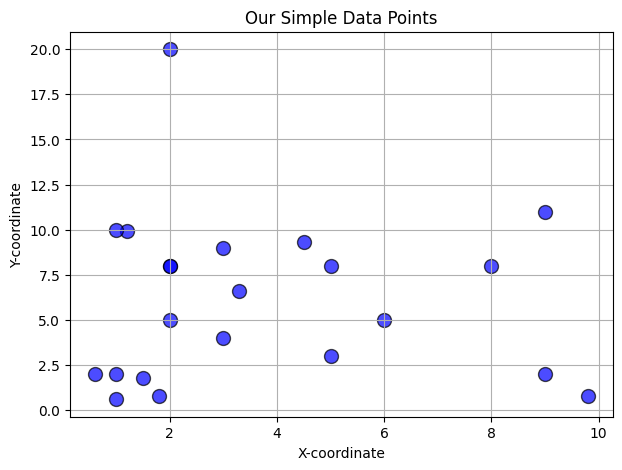

In [14]:
# Visualize our initial data points
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=100, c='blue', alpha=0.7, edgecolor='black')
plt.title('Our Simple Data Points')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(True)
plt.show()

In [16]:
# Now, let's apply K-Means!
# We decide we want 2 clusters (K=2)
# n_init=10 means it will run the algorithm 10 times with different random starting points
# and pick the best result. This makes it more robust.
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)

# Fit the model to our data (this is where it finds the clusters)
kmeans.fit(X)

# Get the cluster labels for each data point (which cluster each point belongs to)
labels = kmeans.labels_

# Get the coordinates of the cluster centers (where the 'middle' of each cluster ended up)
centroids = kmeans.cluster_centers_

print("Assigned cluster for each data point:", labels)
print("Final cluster centers:\n", centroids)

Assigned cluster for each data point: [1 1 0 0 1 0 0 1 0 1 0 2 0 1 1 1 1 1 1 0 0 0]
Final cluster centers:
 [[ 3.9         8.78      ]
 [ 3.7         2.45454545]
 [ 2.         20.        ]]


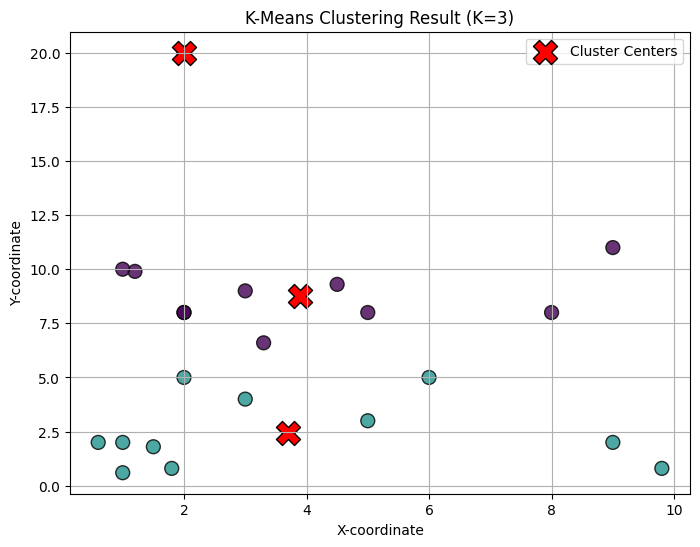

In [19]:
# Visualize the results with clusters and centroids
plt.figure(figsize=(8, 6))

# Plot the data points, colored by their assigned cluster
# cmap='viridis' gives different colors for different clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, s=100, cmap='viridis', alpha=0.8, edgecolor='black')

# Plot the cluster centroids in red 'X' markers
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=300, marker='X', label='Cluster Centers', edgecolor='black')

plt.title('K-Means Clustering Result (K=3)')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Assuming X and labels are already defined from previous K-Means execution
# If not, you might need to run the K-Means cell first or re-define them here.

# Create empty lists for each cluster
cluster_0_points = []
cluster_1_points = []
cluster_2_points = []

# Iterate through the data points and their assigned labels
for i in range(len(X)):
    if labels[i] == 0:
      cluster_0_points.append(X[i].tolist()) # Convert numpy array point to list
    elif labels[i] == 1:
      cluster_1_points.append(X[i].tolist())
    else:
      cluster_2_points.append(X[i].tolist())

print("Data points in Cluster 0:")
for point in cluster_0_points:
    print(point)

print("\nData points in Cluster 1:")
for point in cluster_1_points:
    print(point)

print("\nData points in Cluster 2:")
for point in cluster_2_points:
    print(point)

Data points in Cluster 0:
[5.0, 8.0]
[8.0, 8.0]
[2.0, 8.0]
[3.0, 9.0]
[1.2, 9.9]
[1.0, 10.0]
[9.0, 11.0]
[2.0, 8.0]
[3.3, 6.6]
[4.5, 9.3]

Data points in Cluster 1:
[1.0, 2.0]
[1.5, 1.8]
[1.0, 0.6]
[6.0, 5.0]
[3.0, 4.0]
[1.8, 0.8]
[0.6, 2.0]
[9.0, 2.0]
[9.8, 0.8]
[5.0, 3.0]
[2.0, 5.0]

Data points in Cluster 2:
[2.0, 20.0]
